# o1_celltype_scapy_object.py

In [1]:
#load modules
import pandas as pd
import scanpy as sc
import numpy as np
import anndata as ad
import os
from collections import Counter
from sklearn.decomposition import PCA

#ploting modules
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns


working_dic="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/scanpy_object/"
output_path="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/scanpy_object/cell_type/"
os.chdir(working_dic)


#color key define
dimplot_color=mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["#E5E5E5","#4C4DB7"])

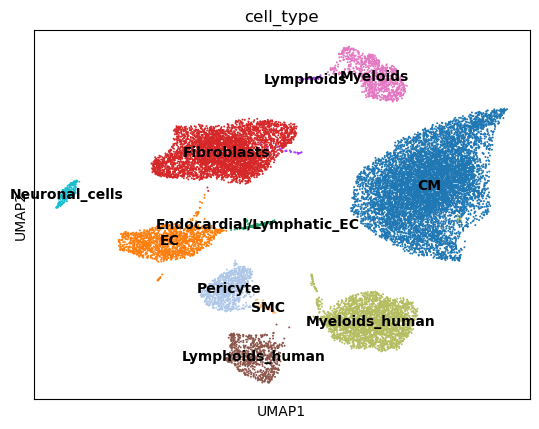

In [2]:
#read in qc filtered and doublet removed scanpy object
adata_raw=sc.read("Humanxeno_raw.h5ad")
adata_afterinte=sc.read("Humanxeno_annot.h5ad")

sc.pl.umap(adata_afterinte, color=["cell_type"], size = 8, legend_loc="on data")

In [3]:
#-------Seperate cell types-------
#transfer the cell type label
adata_raw.obs=adata_afterinte.obs

unique_cell_types = adata_raw.obs['cell_type'].unique()

# Loop through each cell type
for cell_type in unique_cell_types:
    # Subset the AnnData object for the current cell type
    adata_subset = adata_raw[adata_raw.obs['cell_type'] == cell_type, :].copy()

    # Save the subsetted AnnData object
    # Replace spaces with underscores to avoid issues in file naming
    file_name = f"{cell_type.replace(' ', '_')}_subset.h5ad"
    adata_subset.write(file_name)

FileNotFoundError: [Errno 2] Unable to synchronously create file (unable to open file: name = 'Endocardial/Lymphatic_EC_subset.h5ad', errno = 2, error message = 'No such file or directory', flags = 13, o_flags = 602)

In [ ]:
#-------Seperate pericytes and SMC-------
#transfer the cell type label
adata_raw.obs=adata_afterinte.obs
cell_types = ['Pericyte', 'SMC']  # Add more types if needed
adata_subset = adata_raw[adata_raw.obs['cell_type'].isin(cell_types), :].copy()

file_type="Pericyte_SMC"
file_name = f"{file_type.replace(' ', '_')}_subset.h5ad"
adata_subset.write(file_name)